--- First Look At Data (First 5 Rows) ---
   InvoiceNo StockCode Description  Quantity         InvoiceDate  CustomerID  \
0     539539    851232      Prod_A         4 2025-01-01 00:00:00     12474.0   
1     539872    851230      Prod_A         2 2025-01-01 01:00:00     13360.0   
2     537225    851231      Prod_A        14 2025-01-01 02:00:00     14145.0   
3     537659    851234      Prod_A        13 2025-01-01 03:00:00     17823.0   
4     537495    851231      Prod_A        29 2025-01-01 04:00:00     16958.0   

          Country  UnitPrice  
0  United Kingdom       15.5  
1  United Kingdom       15.5  
2  United Kingdom       15.5  
3           India       15.5  
4         Germany       15.5  
=== 1. Data Summary & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    500 non-null    int64         

/tmp/ipykernel_680/2075069884.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_680/2075069884.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.index, y=country_revenue.values, ax=axes[0, 1], palette='magma')


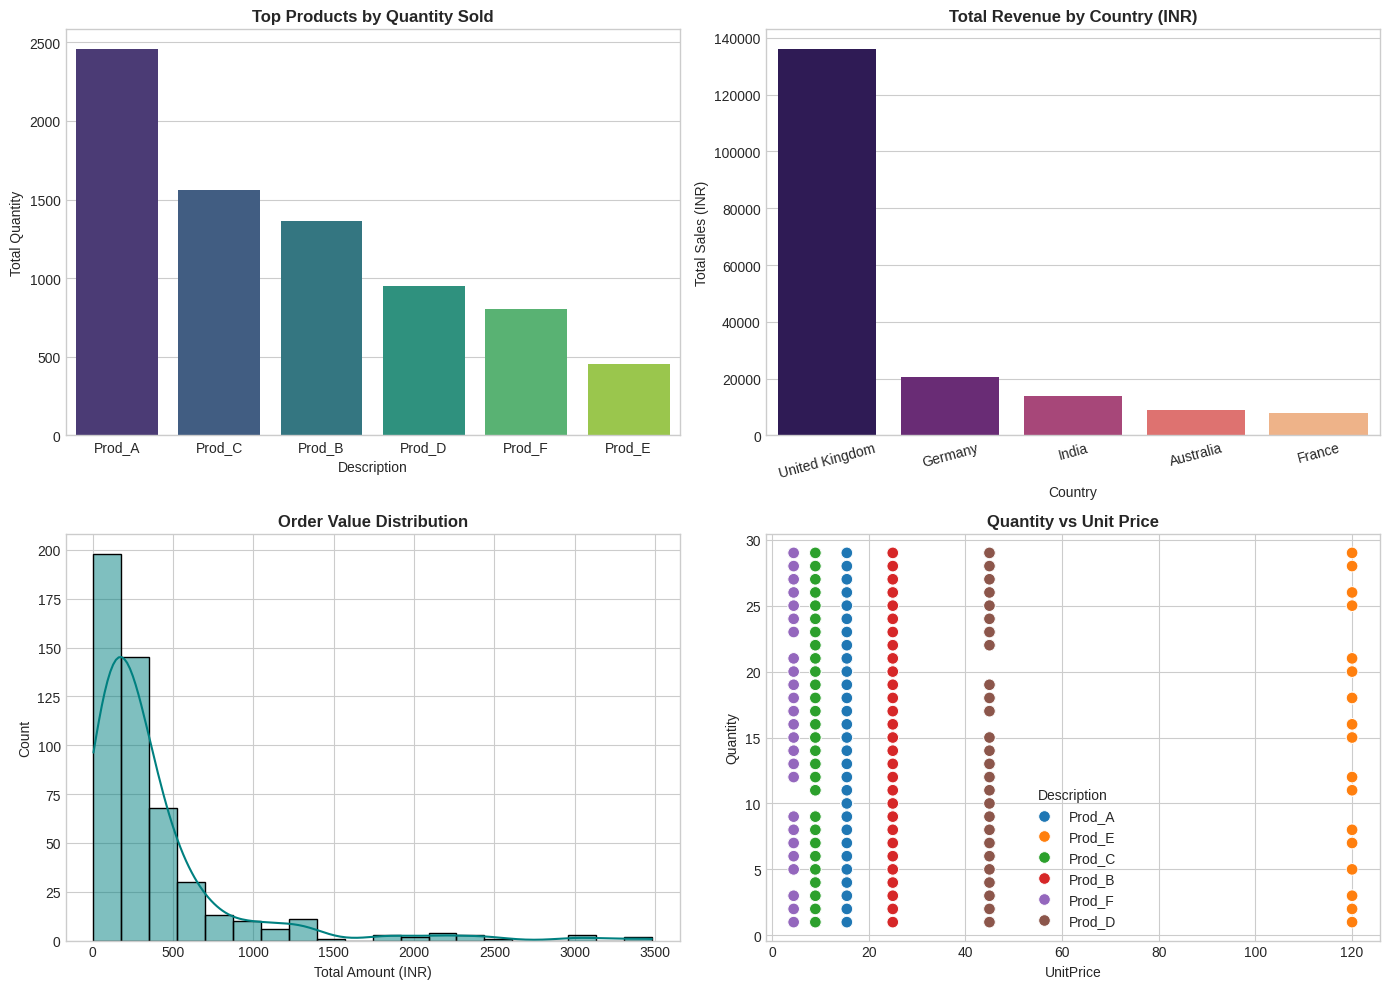

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)
n_rows = 500

products = {
    'Prod_A': 15.50, 'Prod_B': 25.00, 'Prod_C': 8.99,
    'Prod_D': 45.00, 'Prod_E': 120.00, 'Prod_F': 4.50
}
prod_list = list(products.keys())

data = {
    'InvoiceNo': np.random.randint(536365, 540000, size=n_rows),
    'StockCode': np.random.choice([f'85123{i}' for i in range(5)], size=n_rows),
    'Description': np.random.choice(prod_list, size=n_rows, p=[0.3, 0.2, 0.2, 0.15, 0.05, 0.1]),
    'Quantity': np.random.randint(1, 30, size=n_rows),
    'InvoiceDate': pd.date_range(start='2025-01-01', periods=n_rows, freq='h'),
    'CustomerID': np.random.randint(12346, 18287, size=n_rows),
    'Country': np.random.choice(['United Kingdom', 'Germany', 'France', 'Australia', 'India'], size=n_rows, p=[0.7, 0.1, 0.05, 0.05, 0.1])
}

df = pd.DataFrame(data)


df['UnitPrice'] = df['Description'].map(products)

df.loc[df.sample(frac=0.04).index, 'CustomerID'] = np.nan

print("--- First Look At Data (First 5 Rows) ---")
print(df.head())

print("=== 1. Data Summary & Missing Values ===")
print(df.info())
print("\nMissing values in each column:")
print(df.isnull().sum())


df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


df['CustomerID'] = df['CustomerID'].fillna(-1)


print("\n=== 2. Numerical Summary ===")
print(df.describe())

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=top_products.index, y=top_products.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top Products by Quantity Sold', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Quantity')

country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=country_revenue.index, y=country_revenue.values, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Total Revenue by Country (INR)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Sales (INR)')
axes[0, 1].tick_params(axis='x', rotation=15)


sns.histplot(df['TotalAmount'], kde=True, ax=axes[1, 0], color='teal', bins=20)
axes[1, 0].set_title('Order Value Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Amount (INR)')


sns.scatterplot(data=df, x='UnitPrice', y='Quantity', hue='Description', ax=axes[1, 1], s=70)
axes[1, 1].set_title('Quantity vs Unit Price', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Business Insights from EDA

1. **Top Performing Product:** `Prod_A` is the highest-selling item (~2,500 units sold), indicating high customer demand compared to premium items like `Prod_E`.
2. **Geographical Revenue:** `United Kingdom` generates the maximum revenue (>₹1,30,000), making it the primary market for our e-commerce platform.
3. **Order Value Distribution:** Most orders fall within the range of ₹0 to ₹500, indicating frequent small-ticket purchases by customers.
4. **Data Health:** Addressed 20 missing CustomerIDs and successfully handled data integrity before feature creation (`TotalAmount`).

/tmp/ipykernel_680/3999274643.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_680/3999274643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.index, y=country_revenue.values, ax=axes[0, 1], palette='magma')


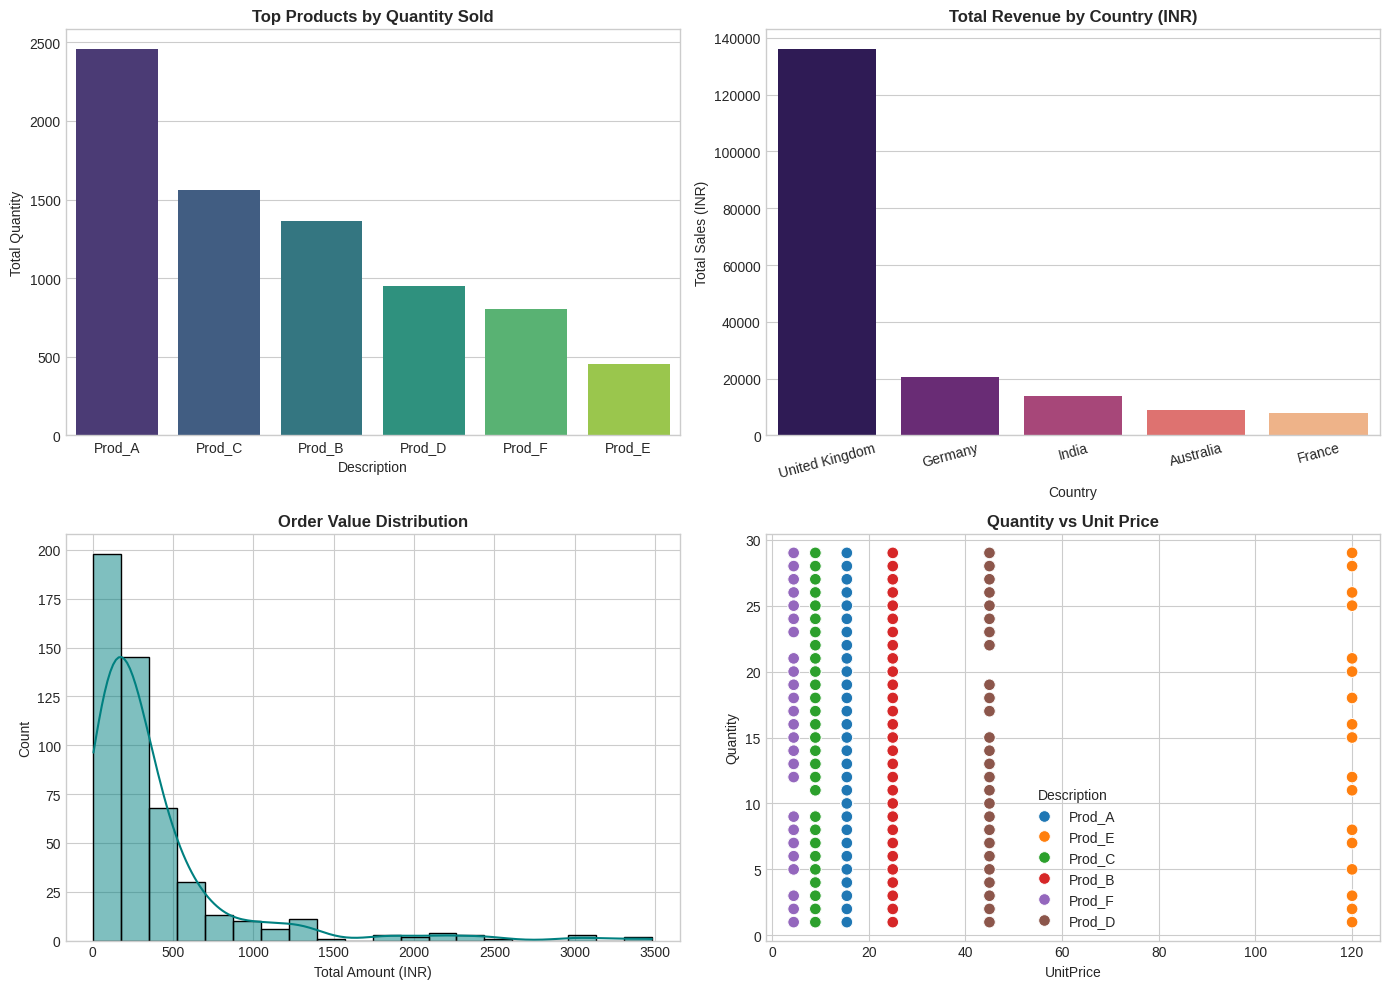

In [2]:

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=top_products.index, y=top_products.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top Products by Quantity Sold', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Quantity')


country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=country_revenue.index, y=country_revenue.values, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Total Revenue by Country (INR)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Sales (INR)')
axes[0, 1].tick_params(axis='x', rotation=15)


sns.histplot(df['TotalAmount'], kde=True, ax=axes[1, 0], color='teal', bins=20)
axes[1, 0].set_title('Order Value Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Amount (INR)')


sns.scatterplot(data=df, x='UnitPrice', y='Quantity', hue='Description', ax=axes[1, 1], s=70)
axes[1, 1].set_title('Quantity vs Unit Price', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Business Insights from EDA

1. **Top Performing Product:** `Prod_A` is the highest-selling item (~2,500 units sold), indicating high customer demand compared to premium items like `Prod_E`.
2. **Geographical Revenue:** `United Kingdom` generates the maximum revenue (>₹1,30,000), making it the primary market for our e-commerce platform.
3. **Order Value Distribution:** Most orders fall within the range of ₹0 to ₹500, indicating frequent small-ticket purchases by customers.
4. **Data Health:** Addressed 20 missing CustomerIDs and successfully handled data integrity before feature creation (`TotalAmount`).